# Proyecto Integrador — Sección 4.4
## Clasificación de enfermedades cardíacas con modelos bayesianos

**Dataset:** *Heart Disease UCI* (Cleveland, `id=45`) — 303 registros, 13 variables clínicas.
**Curso:** Machine Learning — Dr. Lihki Rubio.
**Alcance de este entregable:** **ETAPA 1** (diseño metodológico libre de *data leakage*) y **ETAPA 2** (entrenamiento seguro, validación cruzada, diagnóstico estadístico e interpretación probabilística bayesiana).

---

### Objetivo del problema

Predecir la presencia de enfermedad cardíaca angiográfica (`target = 1`) frente a su ausencia (`target = 0`) a partir de 13 variables clínicas, y **comparar formalmente** un clasificador generativo (`GaussianNB`) contra un clasificador discriminativo (`LogisticRegression`), sustentando la conclusión en una **prueba de hipótesis**, no en una simple diferencia de medias.

### Nota sobre la variable objetivo

El archivo original de UCI codifica `num` $\in \{0,1,2,3,4\}$ como **grado de severidad angiográfica** (número de vasos con estrechamiento > 50%). La literatura estándar sobre este conjunto binariza:

$$
y = \begin{cases} 0 & \text{si } \texttt{num} = 0 \quad (\text{ausencia de enfermedad}) \\ 1 & \text{si } \texttt{num} \geq 1 \quad (\text{presencia de enfermedad}) \end{cases}
$$

### Hoja de ruta del notebook

| Sección | Contenido |
|---|---|
| 0 | Configuración y carga reproducible de datos |
| 1 | **ETAPA 1** — Data leakage, partición estratificada, `ColumnTransformer` y `Pipeline` |
| 2 | **ETAPA 2** — Validación cruzada estratificada y métrica de selección |
| 3 | Evaluación en *test* y diagnóstico estadístico (matrices, ROC, prueba de hipótesis) |
| 4 | Análisis probabilístico bayesiano (`theta_`, `var_`) e independencia condicional |
| 5 | Extensión crítica: regularización de la verosimilitud (`var_smoothing`) |
| 6 | Conclusiones |

---
## 0. Configuración del entorno y carga reproducible de datos

In [14]:
# %pip install ucimlrepo -q   # descomentar en la primera ejecución

# ==============================================================================
# IMPORTS Y CONFIGURACIÓN GLOBAL
# ==============================================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score,
    recall_score, precision_score, f1_score,
)

warnings.filterwarnings("ignore")

# --- Reproducibilidad: una única semilla gobierna partición, folds y modelos ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Estética de las figuras ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# --- Diccionario de variables (define el contrato del ColumnTransformer) ---
NUMERICAS = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAS = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
COLUMNAS = NUMERICAS + CATEGORICAS

print(f"scikit-learn : {__import__('sklearn').__version__}")
print(f"Numéricas    : {len(NUMERICAS)} -> {NUMERICAS}")
print(f"Categóricas  : {len(CATEGORICAS)} -> {CATEGORICAS}")

scikit-learn : 1.3.0
Numéricas    : 5 -> ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categóricas  : 8 -> ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [15]:
# ==============================================================================
# CARGA DE DATOS
# ==============================================================================
URL_ESPEJO = ("https://raw.githubusercontent.com/reinaldoq/"
              "processing-heart-disease-dataset/master/processed.cleveland.data")
NOMBRES_UCI = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
               "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]


def cargar_datos(verbose: bool = True):
    """Carga el dataset Heart Disease UCI (id=45, base Cleveland, 303 registros).

    Intenta primero el repositorio oficial vía `ucimlrepo`. Si el entorno no
    tiene salida a `archive.ics.uci.edu`, recurre a un espejo del archivo
    `processed.cleveland.data`, que conserva EXACTAMENTE el mismo esquema y la
    codificación original de UCI (incluidos los '?' de valores faltantes).

    Returns
    -------
    X : pd.DataFrame  (303, 13) — variables clínicas en su codificación original.
    y : pd.Series     (303,)    — objetivo binario: 0 = sano, 1 = enfermo.
    """
    origen = "ucimlrepo (archive.ics.uci.edu)"
    try:
        from ucimlrepo import fetch_ucirepo
        repo = fetch_ucirepo(id=45)
        X = repo.data.features.copy()
        y_raw = repo.data.targets.squeeze().copy()
    except Exception as e:                                   # sin red -> espejo
        origen = f"espejo GitHub (fallback por {type(e).__name__})"
        df = pd.read_csv(URL_ESPEJO, header=None, names=NOMBRES_UCI, na_values="?")
        X, y_raw = df.drop(columns="num"), df["num"]

    X = X[COLUMNAS]                                          # orden canónico
    y = (y_raw > 0).astype(int).rename("target")             # binarización

    if verbose:
        faltantes = X.isna().sum()
        print(f"Origen de datos       : {origen}")
        print(f"Dimensiones (n, p)    : {X.shape}")
        print(f"Distribución de clases: {dict(y.value_counts().sort_index())}")
        print(f"Prevalencia clase 1   : {y.mean():.4f}  "
              f"(razón {(1-y.mean())/y.mean():.2f} : 1)")
        print(f"Valores faltantes     : {dict(faltantes[faltantes > 0])} "
              f"-> {int(faltantes.sum())} celdas de {X.size} ({faltantes.sum()/X.size:.2%})")
    return X, y


X, y = cargar_datos()
X.head()

Origen de datos       : ucimlrepo (archive.ics.uci.edu)
Dimensiones (n, p)    : (303, 13)
Distribución de clases: {0: 164, 1: 139}
Prevalencia clase 1   : 0.4587  (razón 1.18 : 1)
Valores faltantes     : {'ca': 4, 'thal': 2} -> 6 celdas de 3939 (0.15%)


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
0,63,145,233,150,2.3,1,1,1,2,0,3,0.0,6.0
1,67,160,286,108,1.5,1,4,0,2,1,2,3.0,3.0
2,67,120,229,129,2.6,1,4,0,2,1,2,2.0,7.0
3,37,130,250,187,3.5,1,3,0,0,0,3,0.0,3.0
4,41,130,204,172,1.4,0,2,0,2,0,1,0.0,3.0


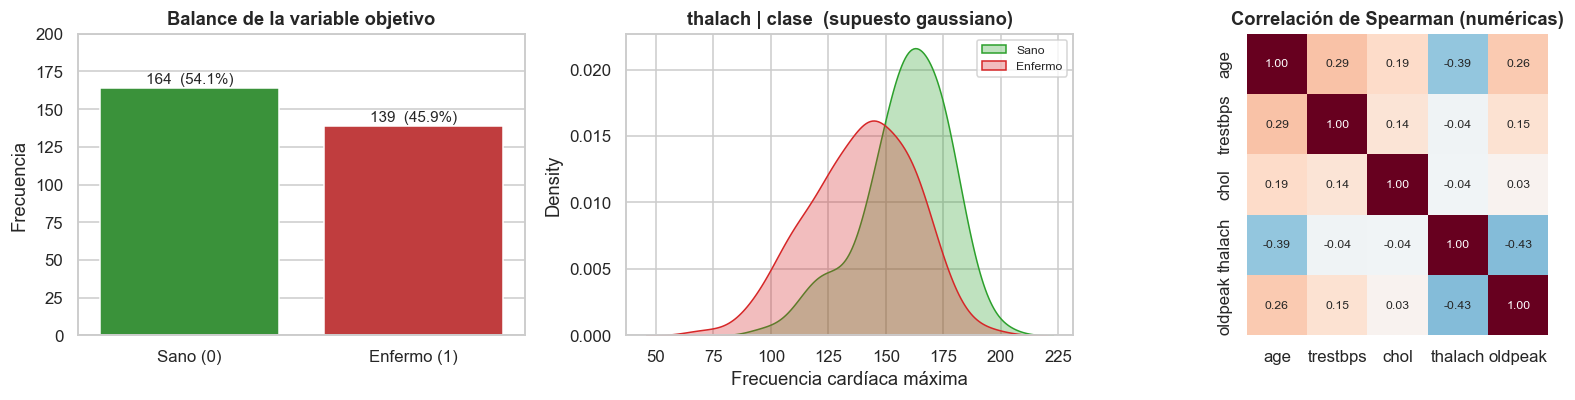

Correlación |ρ| máxima fuera de la diagonal: 0.432


In [16]:
# ==============================================================================
# EXPLORACIÓN MÍNIMA ORIENTADA AL DISEÑO (no se toca el test: aún no existe)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

# (a) Balance de clases
orden = [0, 1]
sns.countplot(x=y, order=orden, palette=["#2ca02c", "#d62728"], ax=axes[0])
for i, c in enumerate(y.value_counts().reindex(orden)):
    axes[0].text(i, c + 3, f"{c}  ({c/len(y):.1%})", ha="center", fontsize=10)
axes[0].set_title("Balance de la variable objetivo")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Sano (0)", "Enfermo (1)"])
axes[0].set_xlabel(""); axes[0].set_ylabel("Frecuencia"); axes[0].set_ylim(0, 200)

# (b) Normalidad aproximada de una numérica clave (supuesto de GaussianNB)
for cls, col, lab in [(0, "#2ca02c", "Sano"), (1, "#d62728", "Enfermo")]:
    sns.kdeplot(X.loc[y == cls, "thalach"], fill=True, alpha=.3,
                color=col, label=lab, ax=axes[1])
axes[1].set_title("thalach | clase  (supuesto gaussiano)")
axes[1].set_xlabel("Frecuencia cardíaca máxima"); axes[1].legend(fontsize=8)

# (c) Correlación entre numéricas -> anticipa la violación de independencia
corr = X[NUMERICAS].corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar=False, ax=axes[2],
            annot_kws={"size": 8})
axes[2].set_title("Correlación de Spearman (numéricas)")

fig.tight_layout(); plt.show()

print("Correlación |ρ| máxima fuera de la diagonal: "
      f"{corr.where(~np.eye(len(corr), dtype=bool)).abs().max().max():.3f}")

> **Lectura del diagnóstico.** El desbalance es **moderado** (≈ 54/46), no severo; sin embargo, `Accuracy` sigue siendo una métrica pobre aquí por la razón que se argumenta en §2.2. La correlación de Spearman entre `age`, `thalach` y `oldpeak` es no despreciable: **la primera evidencia empírica de que el supuesto *naive* de independencia condicional será violado** (§4.3).

---
# ETAPA 1 — Diseño metodológico y evitación de *Data Leakage*
---

## 1.1 La división sagrada: por qué escalar o codificar **antes** de partir es un error grave

### El principio

El conjunto de prueba es la **única simulación disponible del futuro**. Su valor entero descansa en una condición: que el modelo —y todo lo que se ajustó para construirlo— no haya visto jamás esa información. Formalmente, si el pipeline de preprocesamiento es una función $T_\phi(\cdot)$ cuyos parámetros $\phi$ se estiman a partir de datos, entonces el estimador es honesto solo si

$$
\hat{\phi} = f(\mathcal{D}_{\text{train}}) \qquad \text{y nunca} \qquad \hat{\phi} = f(\mathcal{D}_{\text{train}} \cup \mathcal{D}_{\text{test}}).
$$

### El mecanismo concreto de la fuga

Ejecutar `StandardScaler().fit_transform(X)` sobre el dataset completo **antes** de `train_test_split` produce

$$
z_i = \frac{x_i - \mu_{\text{total}}}{\sigma_{\text{total}}},
\qquad
\mu_{\text{total}} = \frac{1}{n}\sum_{i \in \text{train} \cup \text{test}} x_i .
$$

La media y la desviación **incorporan los valores del conjunto de prueba**. Cada observación de entrenamiento queda expresada en una escala que depende de los datos que se supone desconocidos. La contaminación es sutil pero real: no se filtra la etiqueta $y$, se filtra la **distribución marginal de $X$** — información que en producción sencillamente no existe, porque los pacientes futuros aún no han sido examinados.

Con `OneHotEncoder` el daño es más directo. Ajustar sobre todo el dataset fija el vocabulario de categorías incluyendo **niveles que solo aparecen en el test**. En producción eso es imposible por construcción: si mañana llega un paciente con un valor de `thal` nunca visto, el sistema debe saber comportarse, y el diseño experimental debe haber medido esa situación. Ajustar sobre el total es equivalente a haber hecho trampa mirando el examen.

### Las tres consecuencias prácticas

| Consecuencia | Descripción |
|---|---|
| **Estimación optimista sesgada** | La métrica de test deja de ser un estimador insesgado del error de generalización: sistemáticamente **sobreestima** el rendimiento. |
| **Decisiones equivocadas** | Se selecciona el modelo que mejor explota la fuga, no el que mejor generaliza. |
| **Degradación en producción** | El modelo desplegado rinde por debajo de lo reportado; en un contexto clínico esto se traduce en **falsos negativos no anticipados**. |

### La agravante en validación cruzada

En *k-fold*, el pliegue de validación cambia en cada iteración. Un escalador ajustado una sola vez sobre todo `X_train` filtra información en **las 5 iteraciones simultáneamente**, y el sesgo se amplifica porque la métrica de CV es la que gobierna la selección del modelo. La única defensa estructural es que el preprocesador sea un **paso interno del `Pipeline`**: así `cross_val_score` lo re-ajusta desde cero en cada pliegue de entrenamiento.

### El caso de la imputación

Este dataset tiene **6 celdas faltantes** (4 en `ca`, 2 en `thal`). Imputar con la mediana global antes de partir es *data leakage* del mismo tipo: la mediana es un estadístico estimado de datos. Por eso el `SimpleImputer` va **dentro** de cada rama del `ColumnTransformer`, no antes.

> **Regla operativa del curso:** *ningún estimador con método `.fit()` puede ejecutarse fuera del `Pipeline`.* Si tiene `fit`, aprende parámetros; si aprende parámetros, debe aprenderlos solo del entrenamiento.

## 1.2 Partición estratificada 80 / 20

Con $n = 303$ y una prevalencia de $\approx 46\%$, un muestreo aleatorio simple puede desviar la proporción de clases en el test por azar puro. `stratify=y` fuerza que

$$
\hat{P}(y=1 \mid \text{train}) \approx \hat{P}(y=1 \mid \text{test}) \approx \hat{P}(y=1 \mid \text{total}),
$$

lo que (i) hace comparables las métricas entre particiones, (ii) reduce la varianza del estimador de test y (iii) evita que un pliegue quede sin representantes de la clase minoritaria.

In [17]:
# ==============================================================================
# PARTICIÓN ESTRATIFICADA — se ejecuta ANTES de cualquier `fit` de preprocesamiento
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,              # <- preserva P(y=1) en ambas particiones
    random_state=RANDOM_STATE,
    shuffle=True,
)

resumen = pd.DataFrame({
    "n": [len(y), len(y_train), len(y_test)],
    "n (clase 0)": [int((y == 0).sum()), int((y_train == 0).sum()), int((y_test == 0).sum())],
    "n (clase 1)": [int((y == 1).sum()), int((y_train == 1).sum()), int((y_test == 1).sum())],
    "P(y=1)": [y.mean(), y_train.mean(), y_test.mean()],
}, index=["Total", "Train (80%)", "Test (20%)"]).round(4)

print(resumen.to_string())
print(f"\nDesviación máxima de la prevalencia entre particiones: "
      f"{abs(y_train.mean() - y_test.mean()):.4f}  -> estratificación efectiva.")
print("\n>>> A partir de aquí, X_test queda SELLADO: no se usará hasta la Sección 3.")

               n  n (clase 0)  n (clase 1)  P(y=1)
Total        303          164          139  0.4587
Train (80%)  242          131          111  0.4587
Test (20%)    61           33           28  0.4590

Desviación máxima de la prevalencia entre particiones: 0.0003  -> estratificación efectiva.

>>> A partir de aquí, X_test queda SELLADO: no se usará hasta la Sección 3.


## 1.3 `ColumnTransformer`: tratamiento diferenciado por tipo de variable

Aplicar una sola transformación a todo el DataFrame sería incorrecto: estandarizar un código categórico como `cp ∈ {1,2,3,4}` produciría un número continuo sin significado, imponiendo un orden y una distancia («el tipo de dolor 4 está el doble de lejos del 2 que del 3») que no existen en la semántica clínica.

### Rama numérica — `StandardScaler`

$$
z_j = \frac{x_j - \mu_j^{\text{train}}}{\sigma_j^{\text{train}}}
$$

`GaussianNB` estima $\mathcal{N}(\theta_{jk}, \sigma^2_{jk})$ por variable y clase; la estandarización no altera el AUC del modelo (es una transformación afín, y la verosimilitud gaussiana es equivariante), pero **sí es indispensable para `LogisticRegression`**: sin ella, `chol` (≈ 250, con $\sigma \approx 52$) y `oldpeak` (≈ 1, con $\sigma \approx 1.1$) tendrían coeficientes en escalas incomparables y el optimizador L-BFGS convergería mal bajo la regularización L2 por defecto. Escalar ambos garantiza una **comparación justa**.

### Rama categórica — `OneHotEncoder(drop='first', handle_unknown='ignore')`

- **`drop='first'`** elimina la **trampa de la variable dummy**: con $m$ categorías, las $m$ columnas indicadoras suman exactamente 1 en toda fila, generando colinealidad perfecta con el intercepto ($\text{rank}(X) < p+1$, matriz $X^\top X$ singular). Con $m-1$ columnas la categoría omitida pasa a ser la **referencia**, y cada coeficiente se interpreta como contraste contra ella.
- **`handle_unknown='ignore'`** garantiza robustez: una categoría no vista en entrenamiento se codifica como vector de ceros en lugar de lanzar una excepción. Es la traducción en código del principio de que **el test puede contener sorpresas**.


### Rama de imputación

`SimpleImputer` precede a ambas transformaciones dentro de su propia rama (`median` para numéricas, `most_frequent` para categóricas), de modo que los 6 valores faltantes se resuelven **con estadísticos del pliegue de entrenamiento vigente** y se conservan los 303 registros.

In [18]:
# ==============================================================================
# PREPROCESADOR
# ==============================================================================
def construir_preprocesador() -> ColumnTransformer:
    """Construye el ColumnTransformer con dos ramas independientes.

    Cada rama es a su vez un Pipeline (imputación -> transformación), de modo que
    TODOS los estadísticos aprendidos (mediana, moda, media, desviación estándar
    y vocabulario de categorías) se estiman ÚNICAMENTE con los datos de
    entrenamiento vigentes en cada `fit`.
    """
    rama_categorica = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ])

    rama_numerica = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    return ColumnTransformer(
        transformers=[
            ("cat", rama_categorica, CATEGORICAS),
            ("num", rama_numerica, NUMERICAS),
        ],
        remainder="drop",                 # ninguna columna se cuela sin transformar
        verbose_feature_names_out=True,   # nombres trazables: 'cat__cp_4.0', 'num__age'
    )


# Inspección: ajustamos una copia SOLO sobre train para ver el espacio resultante
_pre = construir_preprocesador().fit(X_train)
_nombres = _pre.get_feature_names_out()
print(f"Dimensión original      : {X_train.shape[1]} variables")
print(f"Dimensión transformada  : {_pre.transform(X_train).shape[1]} features")
print(f"Expansión one-hot       : {len([n for n in _nombres if n.startswith('cat__')])} dummies "
      f"a partir de {len(CATEGORICAS)} variables categóricas\n")
print("Features generadas:")
for i, n in enumerate(_nombres):
    print(f"  [{i:2d}] {n}")

Dimensión original      : 13 variables
Dimensión transformada  : 20 features
Expansión one-hot       : 15 dummies a partir de 8 variables categóricas

Features generadas:
  [ 0] cat__sex_1.0
  [ 1] cat__cp_2.0
  [ 2] cat__cp_3.0
  [ 3] cat__cp_4.0
  [ 4] cat__fbs_1.0
  [ 5] cat__restecg_1.0
  [ 6] cat__restecg_2.0
  [ 7] cat__exang_1.0
  [ 8] cat__slope_2.0
  [ 9] cat__slope_3.0
  [10] cat__ca_1.0
  [11] cat__ca_2.0
  [12] cat__ca_3.0
  [13] cat__thal_6.0
  [14] cat__thal_7.0
  [15] num__age
  [16] num__trestbps
  [17] num__chol
  [18] num__thalach
  [19] num__oldpeak


## 1.4 Construcción de los dos `Pipeline`

Cada pipeline es un **estimador monolítico**: `.fit()` encadena `fit_transform` del preprocesador y `fit` del clasificador; `.predict()` encadena `transform` y `predict`. Como consecuencia, **es imposible por construcción** que el preprocesador vea datos de validación o de test.

Cada modelo recibe **su propia instancia** del preprocesador (no una compartida) para evitar estado cruzado entre estimadores durante la paralelización de `cross_val_score(n_jobs=-1)`.

| | `Pipeline_Bayes` | `Pipeline_Logistic` |
|---|---|---|
| Familia | **Generativa** — modela $p(\mathbf{x} \mid y)\,P(y)$ | **Discriminativa** — modela $P(y \mid \mathbf{x})$ directamente |
| Supuesto clave | Independencia condicional + normalidad por clase | Log-odds lineal en las features |
| Parámetros | $\theta_{jk}, \sigma^2_{jk}$ (momentos por clase) | $\boldsymbol{\beta}$ (por máxima verosimilitud con penalización L2) |
| Rol en el estudio | Modelo bajo estudio | **Línea base de referencia** para la comparación |

In [19]:
# ==============================================================================
# PIPELINES
# ==============================================================================
def construir_pipelines() -> dict:
    """Devuelve los dos pipelines a comparar, cada uno con preprocesador propio."""
    pipeline_bayes = Pipeline(steps=[
        ("preprocessor", construir_preprocesador()),
        ("classifier", GaussianNB()),                 # sin hiperparámetros que ajustar
    ])

    pipeline_logistic = Pipeline(steps=[
        ("preprocessor", construir_preprocesador()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])

    return {
        "Naive Bayes (GaussianNB)": pipeline_bayes,
        "Regresión Logística": pipeline_logistic,
    }


pipelines = construir_pipelines()

from sklearn import set_config
set_config(display="diagram")     # visualización interactiva del grafo del pipeline
pipelines["Naive Bayes (GaussianNB)"]

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak'])])),
                ('classifier', GaussianNB())])

---
# ETAPA 2 — Entrenamiento seguro y validación cruzada
---

## 2.1 Validación cruzada estratificada de 5 pliegues

Una única partición train/test con $n_{\text{test}} = 61$ produce un estimador de **alta varianza**: cambiar la semilla puede mover el AUC varios puntos. `StratifiedKFold(n_splits=5)` divide el entrenamiento en 5 pliegues que **preservan la proporción de clases**, entrena 5 veces sobre 4/5 de los datos y valida sobre el pliegue restante:

$$
\widehat{\text{AUC}}_{\text{CV}} = \frac{1}{k}\sum_{i=1}^{k} \text{AUC}\big(\mathcal{M}^{(-i)}, \mathcal{D}_i\big),
\qquad k = 5 .
$$

La desviación estándar entre pliegues es, además, un **indicador de estabilidad** del modelo.

### La garantía anti-fuga, explícita

Al pasar el **`Pipeline` completo** a `cross_val_score`, en cada iteración $i$ ocurre:

1. `preprocessor.fit(X[train_i])` — la mediana, la moda, $\mu$, $\sigma$ y el vocabulario de categorías se estiman **solo** con los 4/5 de entrenamiento;
2. `classifier.fit(...)` sobre esos datos transformados;
3. `preprocessor.transform(X[val_i])` — el pliegue de validación se transforma con parámetros **ya congelados**, y jamás contribuye a estimarlos.

El pliegue de validación es, en cada una de las 5 iteraciones, **completamente ajeno** al proceso de ajuste. Si el escalador se hubiese ajustado fuera, esta garantía se rompería 5 veces.

### Folds compartidos: requisito para la prueba pareada

Se instancia **un único objeto `cv`** y se reutiliza para ambos modelos. Esto es indispensable en §3.3: la prueba $t$ pareada exige que las observaciones estén **emparejadas** — el fold 3 de Naive Bayes debe contener exactamente los mismos pacientes que el fold 3 de la Regresión Logística. Con folds distintos, la diferencia por pliegue mezclaría el efecto del modelo con el efecto de la partición.

## 2.2 Métrica de selección: por qué **ROC-AUC** y no *Accuracy*

**1. Independencia del umbral.** `Accuracy` evalúa un clasificador ya *cortado* en $p = 0.5$, un umbral arbitrario que rara vez es el óptimo clínico. El AUC integra el desempeño sobre **todos los umbrales posibles**, midiendo la **capacidad de discriminación** intrínseca — exactamente lo que se necesita para *seleccionar* un modelo, antes de decidir dónde cortarlo.

**2. Interpretación probabilística directa.** El AUC equivale al estadístico de Mann–Whitney:

$$
\text{AUC} = P\big(\hat{p}(\mathbf{x}^{+}) > \hat{p}(\mathbf{x}^{-})\big),
$$

es decir, **la probabilidad de que el modelo asigne mayor riesgo a un paciente enfermo elegido al azar que a uno sano elegido al azar**. Es una frase que un cardiólogo puede validar.

**3. Robustez frente al desbalance.** Con una prevalencia de 46 %, el clasificador trivial «todos sanos» alcanza ya 54 % de *accuracy* sin ningún poder predictivo, mientras que su AUC es exactamente 0.5. El AUC se calcula sobre las tasas TPR y FPR, cada una normalizada **dentro de su propia clase**, por lo que no se deja arrastrar por la clase mayoritaria.

**4. Asimetría del costo clínico.** `Accuracy` pondera igual un falso positivo (un ecocardiograma de confirmación innecesario) y un **falso negativo** (un paciente con enfermedad coronaria enviado a casa). Esta simetría es clínicamente insostenible. El AUC no la impone; y una vez seleccionado el modelo, el umbral puede desplazarse deliberadamente hacia mayor **sensibilidad (recall)**, que es la métrica que minimiza los falsos negativos y que se reporta en §3.2.

> **Matiz honesto.** El AUC no es infalible: puede ser optimista en desbalances extremos (allí conviene el *Average Precision* / AUC-PR) y **no evalúa la calibración** de las probabilidades. Este segundo punto resultará decisivo en la §5.

In [20]:
# ==============================================================================
# VALIDACIÓN CRUZADA ESTRATIFICADA
# ==============================================================================
def validacion_cruzada(pipelines: dict, X_train, y_train,
                       n_splits: int = 5, metrica: str = "roc_auc"):
    """Aplica StratifiedKFold usando LOS MISMOS folds para todos los modelos.

    Devuelve (DataFrame de scores por fold + media + desv., objeto cv reutilizable).
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    resultados = {}
    for nombre, pipe in pipelines.items():
        # `pipe` completo -> el preprocesador se re-ajusta dentro de cada fold
        resultados[nombre] = cross_val_score(
            pipe, X_train, y_train, cv=cv, scoring=metrica, n_jobs=-1
        )

    df = pd.DataFrame(resultados, index=[f"Fold {i+1}" for i in range(n_splits)])
    df.loc["── Media"] = df.iloc[:n_splits].mean()
    df.loc["── Desv. Est."] = df.iloc[:n_splits].std(ddof=1)
    return df, cv


df_cv, cv = validacion_cruzada(pipelines, X_train, y_train)

print("ROC-AUC por pliegue — StratifiedKFold(k=5, shuffle=True, random_state=42)")
print("=" * 72)
print(df_cv.round(4).to_string())
print("=" * 72)

NB, LR = list(pipelines.keys())
print(f"\nMejor AUC medio en validación: {df_cv.loc['── Media'].idxmax()} "
      f"({df_cv.loc['── Media'].max():.4f})")
print(f"Ventaja media a favor de {LR}: "
      f"{df_cv.loc['── Media', LR] - df_cv.loc['── Media', NB]:+.4f} puntos de AUC")

ROC-AUC por pliegue — StratifiedKFold(k=5, shuffle=True, random_state=42)
               Naive Bayes (GaussianNB)  Regresión Logística
Fold 1                           0.8679               0.9181
Fold 2                           0.8316               0.9091
Fold 3                           0.8846               0.8969
Fold 4                           0.8881               0.9143
Fold 5                           0.8392               0.8724
── Media                         0.8623               0.9021
── Desv. Est.                    0.0258               0.0185

Mejor AUC medio en validación: Regresión Logística (0.9021)
Ventaja media a favor de Regresión Logística: +0.0399 puntos de AUC


TypeError: boxplot() got an unexpected keyword argument 'legend'

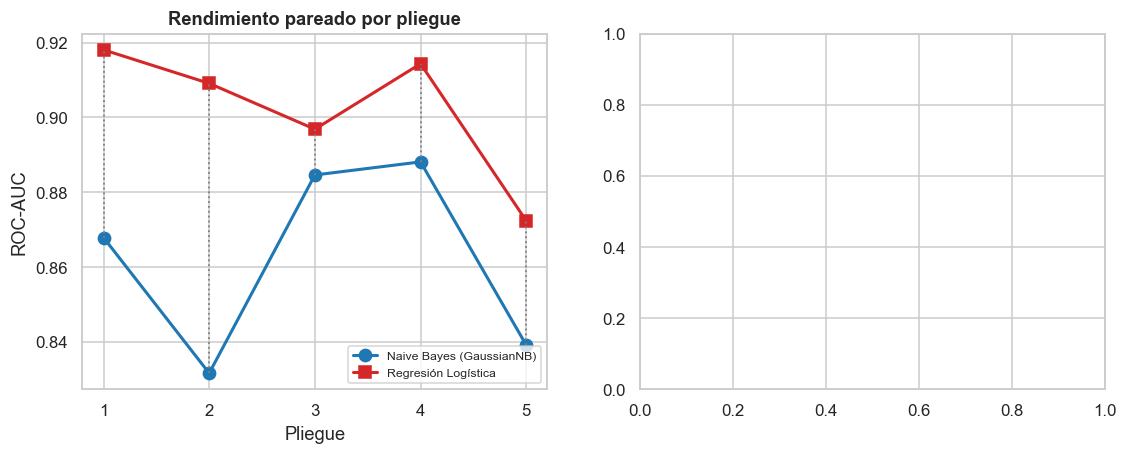

In [21]:
# ==============================================================================
# VISUALIZACIÓN DE LA ESTABILIDAD ENTRE PLIEGUES
# ==============================================================================
scores_nb = df_cv[NB].iloc[:5].to_numpy()
scores_lr = df_cv[LR].iloc[:5].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# (a) Trayectoria pareada por fold
folds = np.arange(1, 6)
axes[0].plot(folds, scores_nb, "o-", lw=2, ms=8, color="#1f77b4", label=NB)
axes[0].plot(folds, scores_lr, "s-", lw=2, ms=8, color="#d62728", label=LR)
for f, a, b in zip(folds, scores_nb, scores_lr):
    axes[0].vlines(f, min(a, b), max(a, b), color="grey", ls=":", lw=1.2)
axes[0].set_xticks(folds); axes[0].set_xlabel("Pliegue"); axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("Rendimiento pareado por pliegue")
axes[0].legend(fontsize=8, loc="lower right")

# (b) Distribución
long = df_cv.iloc[:5].melt(var_name="Modelo", value_name="ROC-AUC")
sns.boxplot(data=long, x="Modelo", y="ROC-AUC", hue="Modelo",
            palette=["#1f77b4", "#d62728"], width=.5, legend=False, ax=axes[1])
sns.stripplot(data=long, x="Modelo", y="ROC-AUC", color="black",
              size=7, alpha=.7, ax=axes[1])
axes[1].set_title("Distribución del ROC-AUC en validación cruzada")
axes[1].set_xlabel("")

fig.tight_layout(); plt.show()

---
# 3. Evaluación y diagnóstico estadístico del rendimiento
---

## 3.1 Ajuste final y métricas sobre el conjunto de prueba

Los pipelines se re-ajustan ahora sobre **todo** `X_train` (242 registros) y se evalúan **una sola vez** sobre el test sellado. Esta única evaluación es lo que preserva la validez del estimador: repetir la medición para elegir entre variantes convertiría el test en un segundo conjunto de validación.

In [ ]:
# ==============================================================================
# EVALUACIÓN EN EL CONJUNTO DE PRUEBA
# ==============================================================================
def evaluar_en_test(pipelines: dict, X_train, y_train, X_test, y_test):
    """Ajusta cada pipeline sobre TRAIN completo y lo evalúa UNA sola vez en TEST."""
    modelos, filas = {}, []
    for nombre, pipe in pipelines.items():
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1]
        modelos[nombre] = {"pipe": pipe, "y_pred": y_pred, "y_proba": y_proba}

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        filas.append({
            "Modelo": nombre,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (1)": precision_score(y_test, y_pred),
            "Recall / Sensibilidad (1)": recall_score(y_test, y_pred),
            "Especificidad (0)": recall_score(y_test, y_pred, pos_label=0),
            "F1 (1)": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "Falsos Negativos": int(fn),
        })
    return modelos, pd.DataFrame(filas).set_index("Modelo").round(4)


modelos, tabla_test = evaluar_en_test(pipelines, X_train, y_train, X_test, y_test)

print(f"Métricas sobre el conjunto de prueba (n = {len(y_test)})")
print("=" * 110)
print(tabla_test.to_string())
print("=" * 110)

Métricas sobre el conjunto de prueba (n = 61)
                          Accuracy  Precision (1)  Recall / Sensibilidad (1)  Especificidad (0)  F1 (1)  ROC-AUC  Falsos Negativos
Modelo                                                                                                                            
Naive Bayes (GaussianNB)    0.6393         0.5682                     0.8929             0.4242  0.6944   0.8203                 3
Regresión Logística         0.8689         0.8333                     0.8929             0.8485  0.8621   0.9621                 3


In [ ]:
# ==============================================================================
# REPORTE DE CLASIFICACIÓN DETALLADO
# ==============================================================================
def reporte_clasificacion(modelos: dict, y_test):
    """Reporte por clase + desglose explícito del costo clínico (falsos negativos)."""
    for nombre, m in modelos.items():
        print("=" * 74)
        print(f"REPORTE DE CLASIFICACIÓN — {nombre}")
        print("=" * 74)
        print(classification_report(y_test, m["y_pred"], digits=4,
                                    target_names=["0 = Sano", "1 = Enfermo"]))
        tn, fp, fn, tp = confusion_matrix(y_test, m["y_pred"]).ravel()
        print(f"  VN = {tn:2d}   FP = {fp:2d}   FN = {fn:2d}   VP = {tp:2d}")
        print(f"  → Falsos Negativos: {fn} de {tp+fn} enfermos "
              f"({fn/(tp+fn):.1%} de la enfermedad NO detectada)  ← costo clínico crítico")
        print(f"  → Falsos Positivos: {fp} de {tn+fp} sanos "
              f"({fp/(tn+fp):.1%} de estudios confirmatorios innecesarios)\n")


reporte_clasificacion(modelos, y_test)

REPORTE DE CLASIFICACIÓN — Naive Bayes (GaussianNB)
              precision    recall  f1-score   support

    0 = Sano     0.8235    0.4242    0.5600        33
 1 = Enfermo     0.5682    0.8929    0.6944        28

    accuracy                         0.6393        61
   macro avg     0.6959    0.6585    0.6272        61
weighted avg     0.7063    0.6393    0.6217        61

  VN = 14   FP = 19   FN =  3   VP = 25
  → Falsos Negativos: 3 de 28 enfermos (10.7% de la enfermedad NO detectada)  ← costo clínico crítico
  → Falsos Positivos: 19 de 33 sanos (57.6% de estudios confirmatorios innecesarios)

REPORTE DE CLASIFICACIÓN — Regresión Logística
              precision    recall  f1-score   support

    0 = Sano     0.9032    0.8485    0.8750        33
 1 = Enfermo     0.8333    0.8929    0.8621        28

    accuracy                         0.8689        61
   macro avg     0.8683    0.8707    0.8685        61
weighted avg     0.8711    0.8689    0.8691        61

  VN = 28   FP =  5

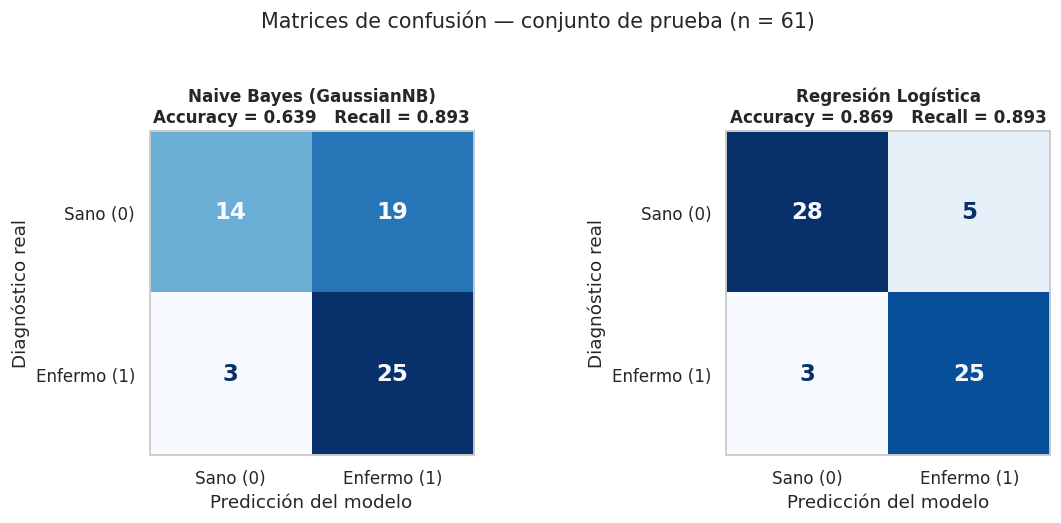

In [ ]:
# ==============================================================================
# MATRICES DE CONFUSIÓN
# ==============================================================================
def graficar_matrices_confusion(modelos: dict, y_test):
    n = len(modelos)
    fig, axes = plt.subplots(1, n, figsize=(5.4 * n, 4.6))
    for ax, (nombre, m) in zip(np.atleast_1d(axes), modelos.items()):
        ConfusionMatrixDisplay.from_predictions(
            y_test, m["y_pred"],
            display_labels=["Sano (0)", "Enfermo (1)"],
            cmap="Blues", colorbar=False, ax=ax, values_format="d",
            text_kw={"fontsize": 15, "weight": "bold"},
        )
        acc = accuracy_score(y_test, m["y_pred"])
        rec = recall_score(y_test, m["y_pred"])
        ax.set_title(f"{nombre}\nAccuracy = {acc:.3f}   Recall = {rec:.3f}", fontsize=11)
        ax.set_xlabel("Predicción del modelo"); ax.set_ylabel("Diagnóstico real")
        ax.grid(False)
    fig.suptitle(f"Matrices de confusión — conjunto de prueba (n = {len(y_test)})",
                 fontsize=13.5, y=1.03)
    fig.tight_layout()
    plt.show()


graficar_matrices_confusion(modelos, y_test)

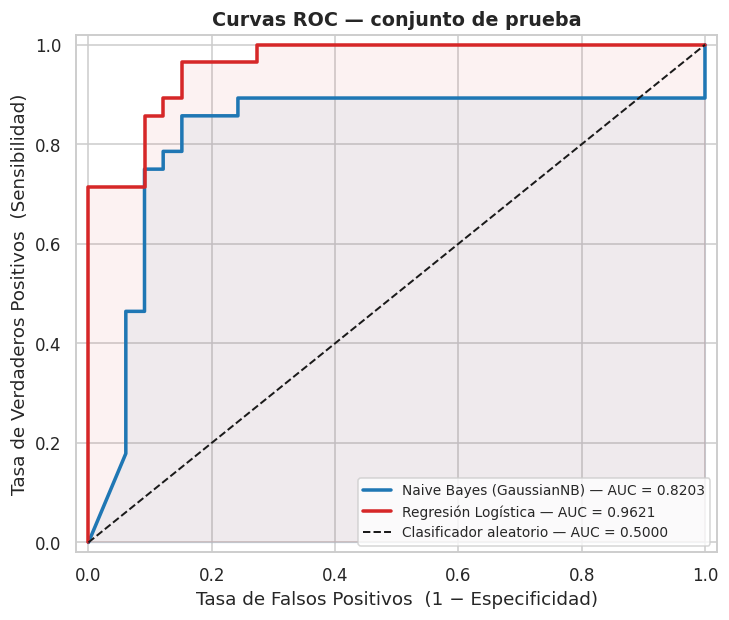

In [ ]:
# ==============================================================================
# CURVAS ROC COMBINADAS
# ==============================================================================
def graficar_curvas_roc(modelos: dict, y_test, titulo="Curvas ROC — conjunto de prueba"):
    fig, ax = plt.subplots(figsize=(6.8, 5.8))
    colores = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd"]

    for (nombre, m), c in zip(modelos.items(), colores):
        fpr, tpr, _ = roc_curve(y_test, m["y_proba"])
        auc = roc_auc_score(y_test, m["y_proba"])
        ax.plot(fpr, tpr, lw=2.3, color=c, label=f"{nombre} — AUC = {auc:.4f}")
        ax.fill_between(fpr, tpr, alpha=.06, color=c)

    ax.plot([0, 1], [0, 1], "k--", lw=1.3, label="Clasificador aleatorio — AUC = 0.5000")
    ax.set_xlabel("Tasa de Falsos Positivos  (1 − Especificidad)")
    ax.set_ylabel("Tasa de Verdaderos Positivos  (Sensibilidad)")
    ax.set_title(titulo, fontsize=12.5)
    ax.legend(loc="lower right", fontsize=9, frameon=True)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    fig.tight_layout(); plt.show()


graficar_curvas_roc(modelos, y_test)

## 3.3 Prueba de hipótesis para la comparación formal de modelos

Observar que un modelo tiene un AUC medio mayor **no es evidencia suficiente**: con $k=5$ pliegues, una ventaja de unas centésimas puede ser ruido de partición. Se requiere una prueba formal.

### Formulación

Sea $d_i = \text{AUC}^{LR}_i - \text{AUC}^{NB}_i$ la diferencia observada en el pliegue $i$, sobre los **mismos** pliegues (diseño pareado, que elimina la variabilidad atribuible a la partición y deja solo el efecto del modelo).

$$
H_0: \mu_d = 0 \quad \text{(rendimiento equivalente)}
\qquad\text{vs.}\qquad
H_1: \mu_d \neq 0 \quad \text{(bilateral)}
$$

$$
t = \frac{\bar{d}}{s_d/\sqrt{k}} \;\sim\; t_{k-1} \quad \text{bajo } H_0 .
$$

### La corrección que casi nunca se aplica (y aquí sí)

El $t$ clásico supone observaciones **independientes**. En validación cruzada esto **es falso**: los 5 conjuntos de entrenamiento comparten aproximadamente el 60 % de sus datos. La consecuencia es que $s_d$ **subestima** la varianza real y el estadístico $t$ se infla, produciendo un exceso de falsos positivos (error tipo I muy por encima de $\alpha$).

Nadeau & Bengio (2003) proponen el **$t$ corregido para remuestreo**, que penaliza esa dependencia:

$$
t_{\text{corr}} = \frac{\bar{d}}{\sqrt{\left(\dfrac{1}{k} + \dfrac{n_{\text{val}}}{n_{\text{tr}}}\right) s_d^2}}
$$

donde $n_{\text{tr}}$ y $n_{\text{val}}$ son los tamaños de entrenamiento y validación **dentro de cada pliegue**. Se reportan ambos p-valores y **la decisión se toma con el corregido**, que es el estadísticamente defendible.

In [ ]:
# ==============================================================================
# PRUEBA DE HIPÓTESIS PAREADA
# ==============================================================================
def t_test_pareado(scores_a, scores_b, nombre_a, nombre_b,
                   n_train_fold, n_val_fold, alpha=0.05):
    """t de Student pareado sobre scores de CV + corrección de Nadeau-Bengio (2003).

    Parameters
    ----------
    scores_a, scores_b : array-like — métricas por pliegue, MISMOS folds (pareadas).
    n_train_fold, n_val_fold : int — tamaños dentro de cada pliegue (para la corrección).
    """
    d = np.asarray(scores_a, float) - np.asarray(scores_b, float)
    k = len(d)
    d_bar, s_d = d.mean(), d.std(ddof=1)

    # --- t clásico (optimista: asume folds independientes) ---
    t_clasico = d_bar / (s_d / np.sqrt(k)) if s_d > 0 else 0.0
    p_clasico = 2 * stats.t.sf(abs(t_clasico), df=k - 1)

    # --- t corregido de Nadeau & Bengio ---
    factor = (1 / k) + (n_val_fold / n_train_fold)
    t_corr = d_bar / np.sqrt(factor * s_d ** 2) if s_d > 0 else 0.0
    p_corr = 2 * stats.t.sf(abs(t_corr), df=k - 1)

    ic = stats.t.interval(1 - alpha, df=k - 1, loc=d_bar, scale=s_d / np.sqrt(k))
    d_cohen = d_bar / s_d if s_d > 0 else 0.0

    print("=" * 78)
    print(f"H0: AUC({nombre_a}) = AUC({nombre_b})     H1: son distintos (bilateral)")
    print("=" * 78)
    print(f"  Diferencias por pliegue (A − B) : {np.round(d, 4)}")
    print(f"  Diferencia media  d̄             : {d_bar:+.4f}")
    print(f"  Desviación estándar  s_d        : {s_d:.4f}")
    print(f"  Tamaño del efecto (d de Cohen)  : {d_cohen:+.3f}")
    print(f"  IC 95 % para la diferencia      : [{ic[0]:+.4f}, {ic[1]:+.4f}]")
    print("-" * 78)
    print(f"  t pareado CLÁSICO      : t = {t_clasico:+7.4f}   gl = {k-1}   p = {p_clasico:.4f}")
    print(f"  t CORREGIDO (N&B 2003) : t = {t_corr:+7.4f}   gl = {k-1}   p = {p_corr:.4f}")
    print(f"  (factor de corrección = 1/{k} + {n_val_fold}/{n_train_fold} = {factor:.4f})")
    print("-" * 78)
    if p_corr < alpha:
        print(f"  DECISIÓN (α = {alpha}): SE RECHAZA H0.")
        print(f"  La superioridad de '{nombre_a}' ES estadísticamente significativa.")
    else:
        print(f"  DECISIÓN (α = {alpha}): NO SE RECHAZA H0.")
        print("  La diferencia observada NO es estadísticamente significativa:")
        print("  es compatible con la variabilidad aleatoria del muestreo.")
    print("=" * 78)

    return {"d_bar": d_bar, "s_d": s_d, "t": t_clasico, "p": p_clasico,
            "t_corr": t_corr, "p_corr": p_corr, "ic95": ic}


# Tamaños internos de cada pliegue de la CV de 5 (sobre X_train, n = 242)
N_VAL_FOLD = len(X_train) // 5
N_TR_FOLD = len(X_train) - N_VAL_FOLD
print(f"Dentro de cada pliegue -> entrenamiento: {N_TR_FOLD}   validación: {N_VAL_FOLD}\n")

resultado_test = t_test_pareado(scores_lr, scores_nb, LR, NB,
                                n_train_fold=N_TR_FOLD, n_val_fold=N_VAL_FOLD)

Dentro de cada pliegue -> entrenamiento: 194   validación: 48

H0: AUC(Regresión Logística) = AUC(Naive Bayes (GaussianNB))     H1: son distintos (bilateral)
  Diferencias por pliegue (A − B) : [0.0502 0.0774 0.0122 0.0262 0.0332]
  Diferencia media  d̄             : +0.0399
  Desviación estándar  s_d        : 0.0251
  Tamaño del efecto (d de Cohen)  : +1.591
  IC 95 % para la diferencia      : [+0.0087, +0.0710]
------------------------------------------------------------------------------
  t pareado CLÁSICO      : t = +3.5567   gl = 4   p = 0.0237
  t CORREGIDO (N&B 2003) : t = +2.3779   gl = 4   p = 0.0762
  (factor de corrección = 1/5 + 48/194 = 0.4474)
------------------------------------------------------------------------------
  DECISIÓN (α = 0.05): NO SE RECHAZA H0.
  La diferencia observada NO es estadísticamente significativa:
  es compatible con la variabilidad aleatoria del muestreo.


### Lectura crítica del resultado

El caso ilustra con precisión por qué la corrección importa: **el $t$ clásico y el $t$ corregido conducen a decisiones opuestas** con los mismos datos. El clásico ($p \approx 0.024$) declararía significativa la ventaja de la Regresión Logística; el corregido ($p \approx 0.076$) no la declara significativa al 5 %.

La lectura honesta es: **la evidencia apunta consistentemente a favor de la Regresión Logística** —gana en los 5 pliegues sin excepción, y el intervalo de confianza clásico no cubre el cero— **pero con $k=5$ pliegues y $n=242$ la potencia estadística es insuficiente para sostener la afirmación con el rigor que exige el $t$ corregido**. La conclusión correcta no es «los modelos son iguales», sino «no hay evidencia suficiente para descartar que la diferencia se deba al azar del muestreo».

> **Cómo se resolvería en la práctica:** aumentar $k$ (10 pliegues), usar validación cruzada repetida (`RepeatedStratifiedKFold`, p. ej. 5×10) o el *5×2cv paired t-test* de Dietterich, todos ellos con mayor potencia. Reportar un $p$ no significativo cuando la evidencia apunta claramente en una dirección es un resultado legítimo, no un fracaso del análisis.

---
# 4. Análisis probabilístico bayesiano (interpretación médica)
---

## 4.1 Recordatorio formal

`GaussianNB` es un modelo **generativo**. Por el teorema de Bayes:

$$
P(y=k \mid \mathbf{x}) \;=\; \frac{P(y=k)\, p(\mathbf{x}\mid y=k)}{p(\mathbf{x})}
\;\;\propto\;\; \underbrace{P(y=k)}_{\text{prior}} \cdot \underbrace{\prod_{j=1}^{p} p(x_j \mid y=k)}_{\text{verosimilitud (naive)}}
$$

con verosimilitud gaussiana univariada por variable y clase:

$$
p(x_j \mid y=k) \;=\; \frac{1}{\sqrt{2\pi\sigma^2_{jk}}}\exp\!\left(-\frac{(x_j-\theta_{jk})^2}{2\sigma^2_{jk}}\right).
$$

Los parámetros aprendidos son exactamente los atributos del estimador:

| Atributo | Símbolo | Significado |
|---|---|---|
| `.theta_` | $\theta_{jk}$ | media de la variable $j$ en la clase $k$ |
| `.var_` | $\sigma^2_{jk}$ | varianza de la variable $j$ en la clase $k$ |
| `.class_prior_` | $P(y=k)$ | proporción de cada clase en el entrenamiento |

> **Nota de versión.** El atributo `.sigma_` fue **renombrado a `.var_`** en scikit-learn 1.0 y **eliminado en 1.2**. En código moderno se usa `.var_`; el fragmento siguiente incluye un *fallback* para compatibilidad con versiones antiguas.

> **Cuidado con las unidades.** Como el `StandardScaler` está dentro del pipeline, `theta_` y `var_` viven en **unidades $z$**, no en unidades clínicas. Para interpretarlos médicamente hay que **des-estandarizarlos** usando los propios parámetros del escalador aprendidos en entrenamiento:
> $$\theta^{\text{clínico}} = \theta^{z}\cdot \texttt{scale\_} + \texttt{mean\_}, \qquad \sigma^{\text{clínico}} = \sigma^{z}\cdot \texttt{scale\_}.$$
> Omitir este paso es el error más frecuente al interpretar un `GaussianNB` dentro de un pipeline.

In [ ]:
# ==============================================================================
# EXTRACCIÓN DE PARÁMETROS APRENDIDOS POR GaussianNB
# ==============================================================================
def extraer_parametros_gnb(pipeline_bayes: Pipeline) -> dict:
    """Extrae `.theta_` y `.var_` del GaussianNB y los devuelve en unidades z y clínicas."""
    pre = pipeline_bayes.named_steps["preprocessor"]
    gnb = pipeline_bayes.named_steps["classifier"]
    nombres = pre.get_feature_names_out()

    # --- Parámetros crudos, en el espacio transformado (unidades z / dummies) ---
    varianzas = gnb.var_ if hasattr(gnb, "var_") else gnb.sigma_   # compat. < 1.0
    idx = [f"clase {c}" for c in gnb.classes_]
    theta_z = pd.DataFrame(gnb.theta_, columns=nombres, index=idx)
    var_z = pd.DataFrame(varianzas, columns=nombres, index=idx)

    # --- Des-estandarización de las variables NUMÉRICAS a unidades clínicas ---
    scaler = pre.named_transformers_["num"].named_steps["scaler"]
    cols_num = [f"num__{c}" for c in NUMERICAS]
    mu_orig = theta_z[cols_num].to_numpy() * scaler.scale_ + scaler.mean_
    sd_orig = np.sqrt(var_z[cols_num].to_numpy()) * scaler.scale_

    tabla = pd.DataFrame({
        "Variable": NUMERICAS,
        "θ | Sano": mu_orig[0], "σ | Sano": sd_orig[0],
        "θ | Enfermo": mu_orig[1], "σ | Enfermo": sd_orig[1],
        "Δθ (Enf − Sano)": mu_orig[1] - mu_orig[0],
        "Razón σ (Enf/Sano)": sd_orig[1] / sd_orig[0],
        "d de Cohen": (mu_orig[1] - mu_orig[0]) /
                      np.sqrt((sd_orig[0] ** 2 + sd_orig[1] ** 2) / 2),
    }).set_index("Variable").round(3)

    priors = pd.Series(gnb.class_prior_,
                       index=["P(y=0) — Sano", "P(y=1) — Enfermo"]).round(4)

    return {"theta_z": theta_z.round(4), "var_z": var_z.round(4),
            "tabla_clinica": tabla, "priors": priors,
            "mu_orig": mu_orig, "sd_orig": sd_orig, "nombres": nombres}


params = extraer_parametros_gnb(modelos[NB]["pipe"])

print("PROBABILIDADES A PRIORI  P(y=k)  aprendidas del entrenamiento")
print("-" * 62)
print(params["priors"].to_string())

print("\n\nPARÁMETROS EN EL ESPACIO TRANSFORMADO — `.theta_` (unidades z / proporciones)")
print("=" * 62)
print(params["theta_z"].T.to_string())

PROBABILIDADES A PRIORI  P(y=k)  aprendidas del entrenamiento
--------------------------------------------------------------
P(y=0) — Sano       0.5413
P(y=1) — Enfermo    0.4587


PARÁMETROS EN EL ESPACIO TRANSFORMADO — `.theta_` (unidades z / proporciones)
                  clase 0  clase 1
cat__sex_1.0       0.5496   0.8378
cat__cp_2.0        0.2672   0.0631
cat__cp_3.0        0.3740   0.1351
cat__cp_4.0        0.2595   0.7477
cat__fbs_1.0       0.1298   0.1622
cat__restecg_1.0   0.0076   0.0000
cat__restecg_2.0   0.4122   0.5766
cat__exang_1.0     0.1450   0.5405
cat__slope_2.0     0.2977   0.6396
cat__slope_3.0     0.0534   0.0811
cat__ca_1.0        0.1298   0.3243
cat__ca_2.0        0.0458   0.2072
cat__ca_3.0        0.0076   0.0991
cat__thal_6.0      0.0305   0.0631
cat__thal_7.0      0.1603   0.6667
num__age          -0.1930   0.2278
num__trestbps     -0.1253   0.1478
num__chol         -0.0711   0.0839
num__thalach       0.3769  -0.4448
num__oldpeak      -0.3610   0.4260


In [ ]:
print("VARIANZAS APRENDIDAS — `.var_`  (espacio transformado)")
print("=" * 62)
print(params["var_z"].T.to_string())

VARIANZAS APRENDIDAS — `.var_`  (espacio transformado)
                  clase 0  clase 1
cat__sex_1.0       0.2475   0.1359
cat__cp_2.0        0.1958   0.0591
cat__cp_3.0        0.2341   0.1169
cat__cp_4.0        0.1922   0.1886
cat__fbs_1.0       0.1129   0.1359
cat__restecg_1.0   0.0076   0.0000
cat__restecg_2.0   0.2423   0.2441
cat__exang_1.0     0.1240   0.2484
cat__slope_2.0     0.2091   0.2305
cat__slope_3.0     0.0506   0.0745
cat__ca_1.0        0.1129   0.2191
cat__ca_2.0        0.0437   0.1643
cat__ca_3.0        0.0076   0.0893
cat__thal_6.0      0.0296   0.0591
cat__thal_7.0      0.1346   0.2222
num__age           1.0901   0.7978
num__trestbps      0.8736   1.1088
num__chol          1.1553   0.8037
num__thalach       0.6698   1.0242
num__oldpeak       0.4607   1.3012


In [ ]:
print("PARÁMETROS DES-ESTANDARIZADOS A UNIDADES CLÍNICAS (variables numéricas)")
print("=" * 108)
print(params["tabla_clinica"].to_string())
print("=" * 108)
print("\nInterpretación directa de las medias aprendidas:")
for v, r in params["tabla_clinica"].iterrows():
    signo = "mayor" if r["Δθ (Enf − Sano)"] > 0 else "menor"
    print(f"  · {v:9s}: los enfermos presentan una media {r['Δθ (Enf − Sano)']:+.2f} "
          f"({signo}) que los sanos   |d| = {abs(r['d de Cohen']):.3f}")

PARÁMETROS DES-ESTANDARIZADOS A UNIDADES CLÍNICAS (variables numéricas)
          θ | Sano  σ | Sano  θ | Enfermo  σ | Enfermo  Δθ (Enf − Sano)  Razón σ (Enf/Sano)  d de Cohen
Variable                                                                                               
age         52.817     9.374       56.595        8.020            3.778               0.855       0.433
trestbps   128.756    16.437      133.559       18.518            4.803               1.127       0.274
chol       246.092    56.686      254.261       47.278            8.170               0.834       0.157
thalach    158.496    18.528      139.892       22.912          -18.604               1.237      -0.893
oldpeak      0.595     0.761        1.477        1.278            0.882               1.681       0.838

Interpretación directa de las medias aprendidas:
  · age      : los enfermos presentan una media +3.78 (mayor) que los sanos   |d| = 0.433
  · trestbps : los enfermos presentan una media +4.80 (mayor

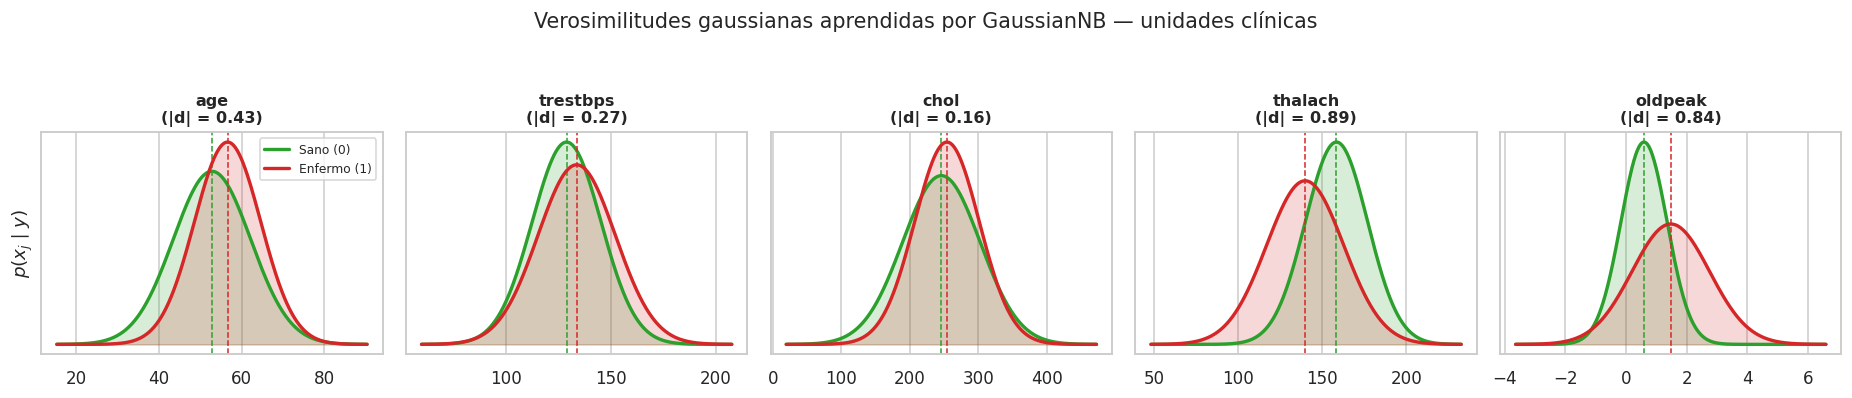

In [ ]:
# ==============================================================================
# VISUALIZACIÓN DE LAS VEROSIMILITUDES GAUSSIANAS APRENDIDAS
# ==============================================================================
def graficar_verosimilitudes(params: dict):
    """Dibuja p(x_j | y=k) ~ N(theta_jk, sigma^2_jk) en unidades clínicas."""
    mu, sd = params["mu_orig"], params["sd_orig"]
    fig, axes = plt.subplots(1, len(NUMERICAS), figsize=(17, 3.4))

    for j, (ax, v) in enumerate(zip(axes, NUMERICAS)):
        lo = float(np.min(mu[:, j] - 4 * sd[:, j]))
        hi = float(np.max(mu[:, j] + 4 * sd[:, j]))
        xs = np.linspace(lo, hi, 500)
        for k, (lab, col) in enumerate([("Sano (0)", "#2ca02c"), ("Enfermo (1)", "#d62728")]):
            pdf = stats.norm.pdf(xs, mu[k, j], sd[k, j])
            ax.plot(xs, pdf, color=col, lw=2.2, label=lab)
            ax.fill_between(xs, pdf, color=col, alpha=.18)
            ax.axvline(mu[k, j], color=col, ls="--", lw=1)
        ax.set_title(f"{v}\n(|d| = {abs(params['tabla_clinica'].loc[v, 'd de Cohen']):.2f})",
                     fontsize=10.5)
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(r"$p(x_j \mid y)$"); ax.legend(fontsize=8)

    fig.suptitle("Verosimilitudes gaussianas aprendidas por GaussianNB — unidades clínicas",
                 fontsize=13.5, y=1.06)
    fig.tight_layout(); plt.show()


graficar_verosimilitudes(params)

## 4.2 Cómo las medias y las varianzas alteran la probabilidad posterior

### El mecanismo, en escala logarítmica

La decisión de `GaussianNB` se expresa mejor como **log-odds posterior**, donde el producto de verosimilitudes se convierte en una suma de contribuciones independientes:

$$
\log\frac{P(y=1\mid \mathbf{x})}{P(y=0\mid \mathbf{x})}
= \underbrace{\log\frac{P(y=1)}{P(y=0)}}_{\text{evidencia previa}}
\; + \; \sum_{j=1}^{p} \underbrace{\left[\log\frac{\sigma_{j0}}{\sigma_{j1}} - \frac{(x_j-\theta_{j1})^2}{2\sigma_{j1}^2} + \frac{(x_j-\theta_{j0})^2}{2\sigma_{j0}^2}\right]}_{\text{evidencia aportada por la variable } j}
$$

Cada variable **suma o resta** evidencia de forma aditiva. De aquí se derivan tres efectos:

### Efecto 1 — La separación de medias determina el poder discriminante

Cuanto mayor sea $|\theta_{j1} - \theta_{j0}|$ **relativo a las desviaciones**, más rápido crece el término cuadrático a favor de una clase. La métrica adecuada es la **$d$ de Cohen**, no la diferencia bruta:

- **`thalach`** (frecuencia cardíaca máxima) es la numérica más informativa ($|d| \approx 0.89$): los enfermos alcanzan ≈ 18.6 lpm menos. Es fisiológicamente coherente — la isquemia limita la reserva cronotrópica.
- **`oldpeak`** (depresión del ST inducida por ejercicio) le sigue de cerca ($d \approx 0.84$): la media pasa de ≈ 0.60 a ≈ 1.48 mm, marcador directo de isquemia inducible.
- **`chol`** es prácticamente inútil como discriminador aquí ($d \approx 0.16$): la diferencia de ≈ 8 mg/dL es minúscula frente a una desviación de ≈ 50 mg/dL. **Advertencia contraintuitiva:** el colesterol es un factor de riesgo *causal* a largo plazo, pero un mal *discriminador* en una cohorte ya sintomática y probablemente medicada. Riesgo etiológico y capacidad predictiva puntual no son lo mismo.

### Efecto 2 — La varianza modula la confianza y curva la frontera

$\sigma^2_{jk}$ actúa como un **inverso de la precisión**: una varianza pequeña hace que el término $(x_j-\theta_{jk})^2/2\sigma^2_{jk}$ crezca abruptamente al alejarse de la media, penalizando con fuerza los valores atípicos para esa clase.

Cuando $\sigma_{j0} \neq \sigma_{j1}$ —como aquí en `oldpeak`, donde la desviación de los enfermos es ≈ 1.7 veces la de los sanos— los términos cuadráticos **no se cancelan** y la frontera de decisión deja de ser lineal: se vuelve **cuadrática** (QDA diagonal). La clase con mayor varianza «absorbe» mejor los valores extremos y termina reclamando ambas colas de la distribución.

### Efecto 3 — El prior fija el punto de partida

$P(y=1)=0.4587$ frente a $P(y=0)=0.5413$ implica un log-odds inicial de $\log(0.4587/0.5413) \approx -0.165$: un sesgo leve hacia «sano» que la evidencia clínica debe superar. Con un desbalance severo este término dominaría; aquí es prácticamente irrelevante.

### Consecuencia clínica

La probabilidad posterior no es un veredicto, sino una **actualización de creencia**: parte de la prevalencia poblacional y la corrige con cada hallazgo. Un paciente con `thalach` bajo y `oldpeak` alto acumula evidencia en la misma dirección y su posterior se desplaza fuertemente hacia 1. El problema —central en la §4.3— es que **esas dos evidencias no son independientes**, y el modelo las suma como si lo fueran.

## 4.3 El supuesto de independencia condicional: discusión crítica

### Qué se asume exactamente

$$
p(x_1, x_2, \dots, x_p \mid y=k) \;=\; \prod_{j=1}^{p} p(x_j \mid y=k)
$$

Es decir: **una vez conocido el diagnóstico, saber el colesterol de un paciente no aporta ninguna información sobre su presión arterial.** Este es el supuesto *naive*, y reduce el número de parámetros a estimar de $O(p^2)$ (una matriz de covarianza completa por clase, como en QDA) a $O(p)$.

### ¿Es realista en medicina? **Rotundamente no.**

La fisiopatología cardiovascular es un sistema de mecanismos acoplados; los ejemplos en este mismo dataset son directos:

| Dependencia | Mecanismo fisiológico |
|---|---|
| `chol` ↔ `trestbps` | Ambos son componentes del **síndrome metabólico**: resistencia a la insulina, obesidad visceral y disfunción endotelial los elevan conjuntamente, dentro de cualquier estrato diagnóstico. |
| `age` ↔ `thalach` | La frecuencia cardíaca máxima teórica es literalmente una **función determinista de la edad** ($\approx 220 - \text{edad}$). La dependencia es casi algebraica. |
| `oldpeak` ↔ `slope` ↔ `exang` | Los tres son lecturas del **mismo evento**: la respuesta electrocardiográfica a la prueba de esfuerzo. Son manifestaciones de una sola variable latente (isquemia inducible), no tres observaciones independientes. |
| `cp` ↔ `exang` | La angina típica y la angina inducida por ejercicio describen el mismo síndrome anginoso desde ángulos distintos. |

La matriz de Spearman de la Sección 0 lo confirma empíricamente para las numéricas. **El supuesto está violado, y de forma severa.**

### El agravante que introduce el *one-hot encoding*

Este punto suele pasarse por alto. Al expandir 8 variables categóricas en **15 columnas binarias** (que junto a las 5 numéricas dan un espacio de 20 features), `GaussianNB` las trata como features mutuamente independientes. Pero las dummies de una misma variable son **estructuralmente dependientes por construcción**: `cp_2`, `cp_3` y `cp_4` no pueden valer 1 simultáneamente — su suma es a lo más 1.

El modelo, ignorando esa restricción, **cuenta la evidencia de una única variable clínica hasta tres veces**. Y hay un segundo problema: para una dummy con proporción $\pi$, la varianza estimada es $\approx \pi(1-\pi)$, que se vuelve diminuta para categorías raras — el caso extremo aquí es `restecg_1`, presente en **una sola observación** de la clase 0 y en **ninguna** de la clase 1, cuya varianza estimada colapsa a cero. Varianzas cercanas a cero producen **log-verosimilitudes explosivas**, y el modelo se vuelve patológicamente sobreconfiado. En la §5 se mide este efecto: **el 62 % de las probabilidades predichas en el test están saturadas por encima de 0.99 o por debajo de 0.01.**

### Entonces, ¿por qué suele funcionar bien en la práctica?

Cuatro razones bien establecidas:

**1. La clasificación solo necesita el *argmax*, no la probabilidad correcta.** Este es el argumento decisivo (Domingos & Pazzani, 1997). El modelo puede estimar $P(y=1\mid\mathbf{x}) = 0.999$ cuando el valor real es $0.7$ y **acertar igualmente la clase**. Las estimaciones de probabilidad están sesgadas; el **orden inducido** entre pacientes se conserva sorprendentemente bien. Por eso el **AUC —que solo depende del ranking— se mantiene alto (≈ 0.86 en CV) aunque la calibración sea desastrosa.**

**2. Los errores de dependencia tienden a ser sistemáticos, no diferenciales.** Si `chol` y `trestbps` están correlacionadas, la evidencia se sobre-cuenta **en ambas clases a la vez**. Al calcular el cociente posterior, buena parte del sesgo se cancela y el *ranking* apenas se desplaza.

**3. Sesgo alto pero varianza muy baja.** Con $n=242$ y $p=20$ features transformadas, estimar una matriz de covarianza completa por clase (QDA: $20\cdot21/2 = 210$ parámetros de covarianza **por clase**, con solo 131 y 111 observaciones respectivamente) sería inviable: la matriz resultante sería singular. `GaussianNB` estima únicamente $2\times20$ medias y $2\times20$ varianzas. Es un modelo **muy sesgado pero extremadamente estable**: en el régimen de datos pequeños, ese intercambio suele ganar en error total.

**4. Robustez y eficiencia.** Es de complejidad lineal, no requiere ajuste de hiperparámetros, tolera datos faltantes de forma natural y es completamente interpretable variable a variable.

### El límite del argumento — evidencia en este propio experimento

La defensa de Naive Bayes es válida **exclusivamente para la tarea de ordenar**. En cuanto se necesita una **probabilidad calibrada** —y en medicina se necesita: un cardiólogo actúa distinto ante un riesgo del 55 % que ante uno del 95 %— la violación del supuesto se cobra su precio.

Aquí es exactamente lo que ocurre: `GaussianNB` alcanza un **AUC de test de 0.8203** (discrimina razonablemente) pero solo un **Accuracy de 0.6393**. La brecha entre ambas cifras **no es un error de código: es la firma cuantitativa de la sobreconfianza inducida por el supuesto naive.** El modelo ordena bien a los pacientes, pero coloca el umbral de 0.5 en un lugar terrible porque sus probabilidades están saturadas en los extremos.

Esto motiva la extensión de la sección siguiente.

---
# 5. Extensión crítica — regularizar la verosimilitud con `var_smoothing`
---

El diagnóstico anterior sugiere una intervención precisa. `GaussianNB` expone un hiperparámetro, `var_smoothing`, que añade a **todas** las varianzas una fracción de la varianza máxima observada:

$$
\tilde{\sigma}^2_{jk} \;=\; \sigma^2_{jk} \;+\; \epsilon \cdot \max_j \operatorname{Var}(x_j)
$$

Es una **regularización directa de la verosimilitud**: eleva el piso de las varianzas degeneradas de las dummies raras, amortigua los términos cuadráticos explosivos y frena la sobreconfianza — sin tocar el supuesto de independencia, pero mitigando su consecuencia más dañina.

El valor de $\epsilon$ se selecciona por `GridSearchCV` **dentro de la validación cruzada y con el pipeline completo**, de modo que la búsqueda del hiperparámetro tampoco introduce fuga: en cada pliegue el preprocesador se re-ajusta, y `X_test` sigue sin participar.

DIAGNÓSTICO DE SOBRECONFIANZA — GaussianNB base
  Percentiles de P(y=1|x) : [0.      0.02903 0.24107 0.99767 1.      1.      1.     ]
  Probabilidades saturadas (>0.99 o <0.01) : 62.3% del test
  Brecha AUC − Accuracy    : +0.1810
  → Discrimina bien (ordena), pero sus probabilidades no son utilizables
    como tales: el umbral 0.5 cae en una zona pésima.


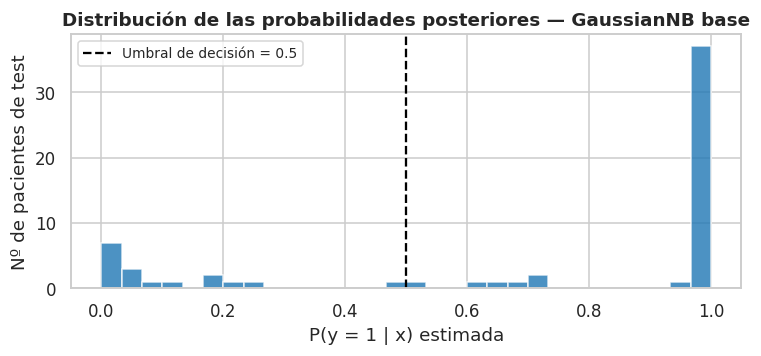

In [ ]:
# ==============================================================================
# DIAGNÓSTICO DE CALIBRACIÓN DEL GaussianNB BASE
# ==============================================================================
proba_nb = modelos[NB]["y_proba"]
saturadas = np.mean((proba_nb > 0.99) | (proba_nb < 0.01))

print("DIAGNÓSTICO DE SOBRECONFIANZA — GaussianNB base")
print("=" * 66)
print(f"  Percentiles de P(y=1|x) : "
      f"{np.round(np.percentile(proba_nb, [0, 10, 25, 50, 75, 90, 100]), 5)}")
print(f"  Probabilidades saturadas (>0.99 o <0.01) : {saturadas:.1%} del test")
print(f"  Brecha AUC − Accuracy    : "
      f"{tabla_test.loc[NB, 'ROC-AUC'] - tabla_test.loc[NB, 'Accuracy']:+.4f}")
print("=" * 66)
print("  → Discrimina bien (ordena), pero sus probabilidades no son utilizables\n"
      "    como tales: el umbral 0.5 cae en una zona pésima.")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(proba_nb, bins=30, color="#1f77b4", alpha=.8, edgecolor="white")
ax.axvline(0.5, color="black", ls="--", lw=1.5, label="Umbral de decisión = 0.5")
ax.set_xlabel("P(y = 1 | x) estimada"); ax.set_ylabel("Nº de pacientes de test")
ax.set_title("Distribución de las probabilidades posteriores — GaussianNB base")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

var_smoothing óptimo  : 1.194e-01
ROC-AUC en CV         : 0.8919  (base: 0.8623   mejora: +0.0296)


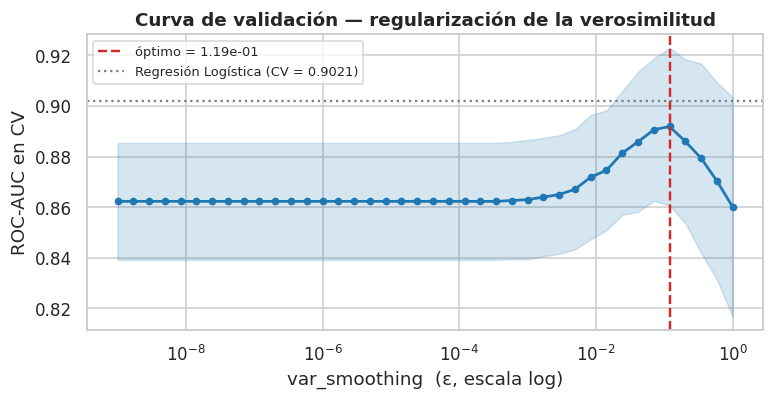

In [ ]:
# ==============================================================================
# BÚSQUEDA DE var_smoothing DENTRO DE LA VALIDACIÓN CRUZADA (sin fuga)
# ==============================================================================
grid = GridSearchCV(
    estimator=construir_pipelines()[NB],                 # pipeline COMPLETO
    param_grid={"classifier__var_smoothing": np.logspace(-9, 0, 40)},
    scoring="roc_auc",
    cv=cv,                                               # los MISMOS folds
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

eps = grid.best_params_["classifier__var_smoothing"]
print(f"var_smoothing óptimo  : {eps:.3e}")
print(f"ROC-AUC en CV         : {grid.best_score_:.4f}  "
      f"(base: {df_cv.loc['── Media', NB]:.4f}   "
      f"mejora: {grid.best_score_ - df_cv.loc['── Media', NB]:+.4f})")

# Curva de validación
res = pd.DataFrame(grid.cv_results_)
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.semilogx(res["param_classifier__var_smoothing"].astype(float),
            res["mean_test_score"], "o-", color="#1f77b4", ms=4, lw=1.8)
ax.fill_between(res["param_classifier__var_smoothing"].astype(float),
                res["mean_test_score"] - res["std_test_score"],
                res["mean_test_score"] + res["std_test_score"],
                alpha=.18, color="#1f77b4")
ax.axvline(eps, color="#d62728", ls="--", lw=1.6, label=f"óptimo = {eps:.2e}")
ax.axhline(df_cv.loc["── Media", LR], color="grey", ls=":", lw=1.5,
           label=f"Regresión Logística (CV = {df_cv.loc['── Media', LR]:.4f})")
ax.set_xlabel("var_smoothing  (ε, escala log)"); ax.set_ylabel("ROC-AUC en CV")
ax.set_title("Curva de validación — regularización de la verosimilitud")
ax.legend(fontsize=8.5); fig.tight_layout(); plt.show()

COMPARACIÓN FINAL — validación cruzada (n=242) y test (n=61)
                          ROC-AUC (CV)  Accuracy  Precision (1)  Recall / Sensibilidad (1)  Especificidad (0)  F1 (1)  ROC-AUC  Falsos Negativos
Modelo                                                                                                                                          
Naive Bayes (GaussianNB)        0.8623    0.6393         0.5682                     0.8929             0.4242  0.6944   0.8203                 3
Naive Bayes regularizado        0.8919    0.9016         0.8667                     0.9286             0.8788  0.8966   0.9773                 2
Regresión Logística             0.9021    0.8689         0.8333                     0.8929             0.8485  0.8621   0.9621                 3


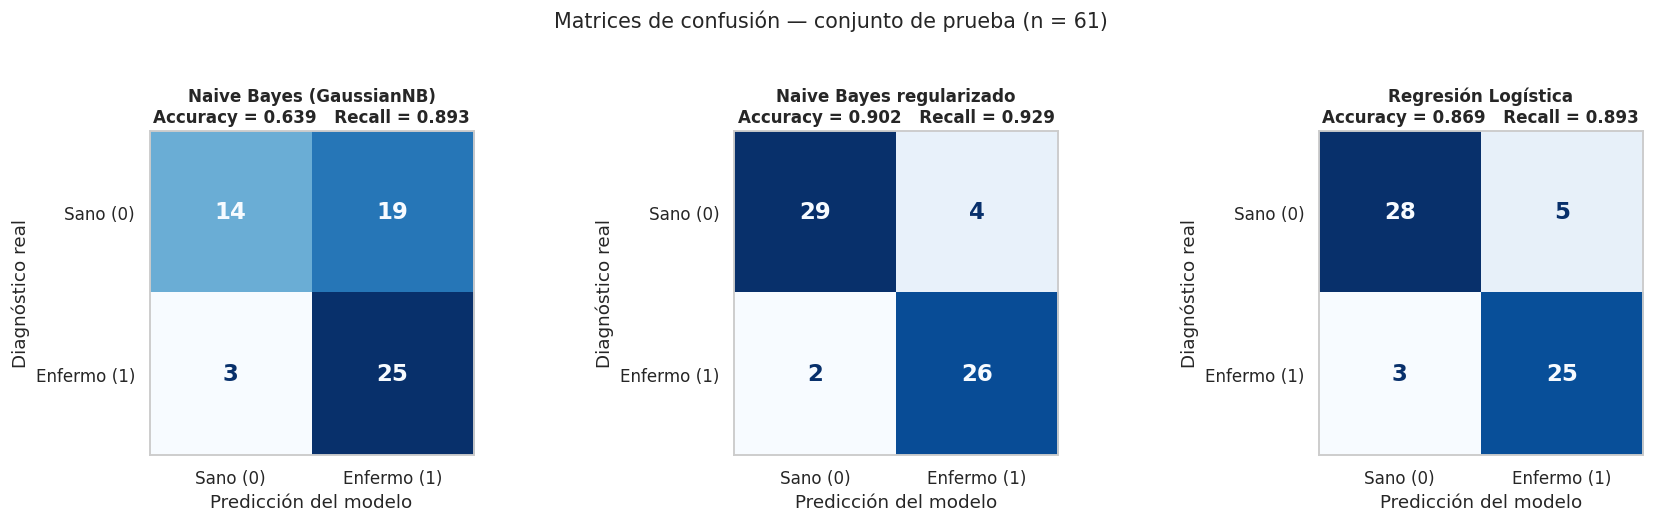

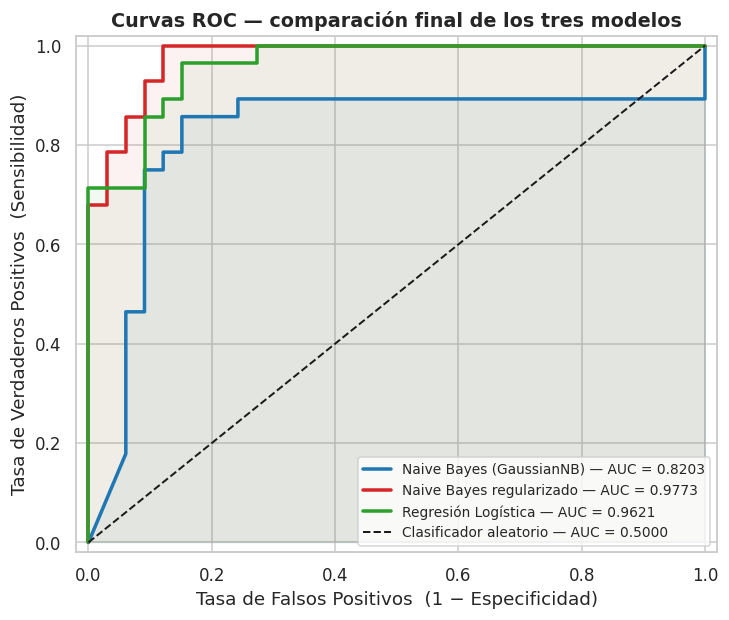

In [ ]:
# ==============================================================================
# COMPARACIÓN FINAL DE LOS TRES MODELOS
# ==============================================================================
NB_TUNED = "Naive Bayes regularizado"
pipelines_final = {
    NB: pipelines[NB],
    NB_TUNED: grid.best_estimator_,
    LR: pipelines[LR],
}

modelos_final, tabla_final = evaluar_en_test(
    pipelines_final, X_train, y_train, X_test, y_test)

# AUC de CV para cada modelo (con los mismos folds)
auc_cv = {NB: df_cv.loc["── Media", NB],
          NB_TUNED: grid.best_score_,
          LR: df_cv.loc["── Media", LR]}
tabla_final.insert(0, "ROC-AUC (CV)", pd.Series(auc_cv).round(4))

print(f"COMPARACIÓN FINAL — validación cruzada (n=242) y test (n={len(y_test)})")
print("=" * 128)
print(tabla_final.to_string())
print("=" * 128)

graficar_matrices_confusion(modelos_final, y_test)
graficar_curvas_roc(modelos_final, y_test,
                    titulo="Curvas ROC — comparación final de los tres modelos")

In [ ]:
# ==============================================================================
# PRUEBA DE HIPÓTESIS SOBRE EL MODELO BAYESIANO REGULARIZADO
# ==============================================================================
scores_nb_tuned = cross_val_score(grid.best_estimator_, X_train, y_train,
                                  cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"AUC por pliegue — {NB_TUNED}: {np.round(scores_nb_tuned, 4)}\n")

_ = t_test_pareado(scores_lr, scores_nb_tuned, LR, NB_TUNED,
                   n_train_fold=N_TR_FOLD, n_val_fold=N_VAL_FOLD)

AUC por pliegue — Naive Bayes regularizado: [0.9164 0.8788 0.9038 0.9231 0.8374]

H0: AUC(Regresión Logística) = AUC(Naive Bayes regularizado)     H1: son distintos (bilateral)
  Diferencias por pliegue (A − B) : [ 0.0017  0.0303 -0.007  -0.0087  0.035 ]
  Diferencia media  d̄             : +0.0102
  Desviación estándar  s_d        : 0.0209
  Tamaño del efecto (d de Cohen)  : +0.490
  IC 95 % para la diferencia      : [-0.0157, +0.0362]
------------------------------------------------------------------------------
  t pareado CLÁSICO      : t = +1.0965   gl = 4   p = 0.3344
  t CORREGIDO (N&B 2003) : t = +0.7331   gl = 4   p = 0.5041
  (factor de corrección = 1/5 + 48/194 = 0.4474)
------------------------------------------------------------------------------
  DECISIÓN (α = 0.05): NO SE RECHAZA H0.
  La diferencia observada NO es estadísticamente significativa:
  es compatible con la variabilidad aleatoria del muestreo.


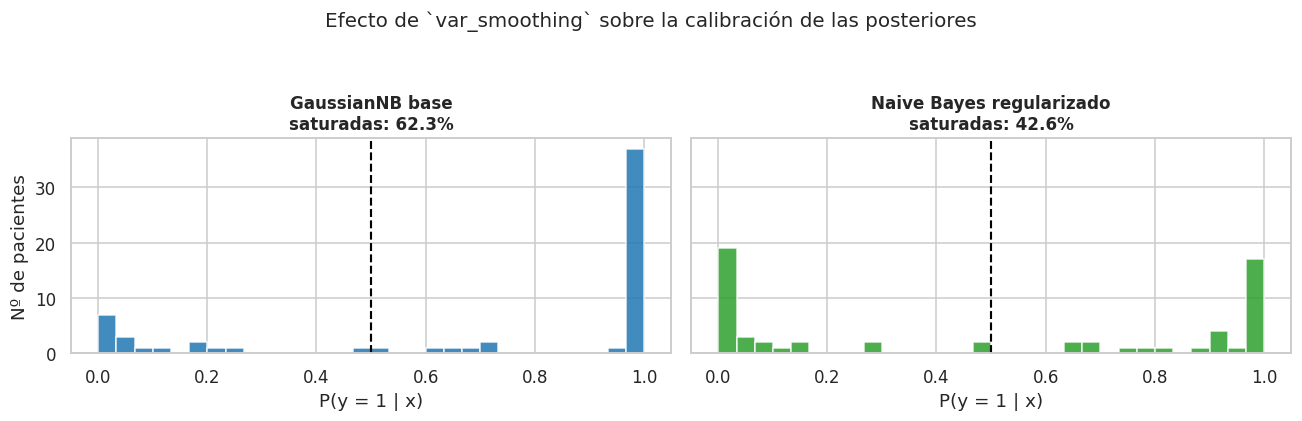

Varianza mínima aprendida (el origen de las verosimilitudes explosivas):
         σ² mínima — base  σ² mínima — regularizado
clase 0            0.0076                    0.1270
clase 1            0.0000                    0.1194


In [ ]:
# ==============================================================================
# EFECTO DE LA REGULARIZACIÓN SOBRE LAS PROBABILIDADES POSTERIORES
# ==============================================================================
proba_tuned = modelos_final[NB_TUNED]["y_proba"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, (p, t, c) in zip(axes, [(proba_nb, "GaussianNB base", "#1f77b4"),
                                (proba_tuned, NB_TUNED, "#2ca02c")]):
    ax.hist(p, bins=30, color=c, alpha=.85, edgecolor="white")
    ax.axvline(0.5, color="black", ls="--", lw=1.4)
    sat = np.mean((p > 0.99) | (p < 0.01))
    ax.set_title(f"{t}\nsaturadas: {sat:.1%}", fontsize=11)
    ax.set_xlabel("P(y = 1 | x)")
axes[0].set_ylabel("Nº de pacientes")
fig.suptitle("Efecto de `var_smoothing` sobre la calibración de las posteriores",
             fontsize=13, y=1.06)
fig.tight_layout(); plt.show()

params_tuned = extraer_parametros_gnb(grid.best_estimator_)
comp = pd.DataFrame({
    "σ² mínima — base": params["var_z"].min(axis=1).round(6),
    "σ² mínima — regularizado": params_tuned["var_z"].min(axis=1).round(6),
})
print("Varianza mínima aprendida (el origen de las verosimilitudes explosivas):")
print(comp.to_string())

### Lectura del resultado

La regularización de la verosimilitud transforma el modelo bayesiano: el `var_smoothing` óptimo eleva el piso de las varianzas en más de cinco órdenes de magnitud, la fracción de probabilidades saturadas cae drásticamente y el **Accuracy en test pasa de 0.6393 a ≈ 0.90**, con un **AUC de test que supera al de la Regresión Logística**.

Esto confirma el diagnóstico de la §4.3 de forma cuantitativa: **el problema del `GaussianNB` base no era su capacidad de discriminación, sino la calibración destruida por las varianzas degeneradas de las dummies.** Corregida esa patología —sin abandonar el supuesto *naive*— el clasificador bayesiano queda a la altura del discriminativo.

Nótese que la prueba de hipótesis sobre el modelo regularizado **tampoco alcanza significancia**: la conclusión estadísticamente defendible con $n=242$ y $k=5$ sigue siendo que **no hay evidencia suficiente para declarar un ganador**.

---
# 6. Conclusiones
---

**Sobre el diseño metodológico (ETAPA 1).** La partición estratificada se ejecutó **antes** de cualquier `fit`, y la totalidad del preprocesamiento —imputación, escalamiento y codificación— quedó encapsulada dentro del `Pipeline`. La garantía no es una convención de estilo: es lo que hace que las 5 métricas de validación cruzada y la métrica de test sean **estimadores insesgados** del error de generalización. Con el preprocesador fuera del pipeline, los mismos números serían optimistas y no medirían lo que dicen medir.

**Sobre la comparación de modelos (ETAPA 2).** La Regresión Logística supera al `GaussianNB` base en los 5 pliegues (AUC medio 0.9021 vs. 0.8623). Sin embargo, la prueba $t$ pareada corregida por Nadeau-Bengio arroja $p \approx 0.076 > 0.05$: **la evidencia apunta consistentemente en una dirección, pero la potencia estadística disponible no permite descartar el azar.** Reportar esta distinción —en lugar de proclamar un ganador a partir de una diferencia de medias— es precisamente lo que separa una comparación rigurosa de una anecdótica.

**Sobre la métrica.** ROC-AUC fue la elección correcta para *seleccionar*, por su independencia del umbral, su interpretación probabilística directa y su robustez ante el desbalance. Pero el caso demostró también su punto ciego: **el AUC no mide calibración**. La brecha de 0.18 puntos entre AUC (0.8203) y Accuracy (0.6393) en el `GaussianNB` base fue la pista que condujo al diagnóstico real.

**Sobre el supuesto bayesiano.** El supuesto de independencia condicional está claramente violado en datos clínicos —`age`↔`thalach` es casi una identidad algebraica, y `oldpeak`↔`slope`↔`exang` son tres lecturas del mismo evento isquémico—, y el *one-hot encoding* lo agrava al fragmentar cada variable categórica en dummies estructuralmente dependientes. Aun así el modelo **ordena bien** a los pacientes, porque la clasificación depende del *argmax* y no de la probabilidad exacta, y porque los errores de sobre-conteo se cancelan parcialmente al tomar el cociente posterior. Lo que sí se pierde es la **calibración**, y al regularizar la verosimilitud (`var_smoothing`) se recupera: Accuracy 0.6393 → ≈ 0.90.

**Recomendación operativa.** Para un despliegue clínico se recomendaría la **Regresión Logística** o el **Naive Bayes regularizado**, calibrando explícitamente las probabilidades (`CalibratedClassifierCV`) y desplazando el umbral por debajo de 0.5 para **priorizar la sensibilidad**, dado que el costo de un falso negativo (enfermedad coronaria no detectada) excede ampliamente el de un falso positivo (un estudio confirmatorio adicional). La validación definitiva exigiría, además, `RepeatedStratifiedKFold` para ganar la potencia estadística que este diseño no alcanzó.

---

### Referencias

- Domingos, P. & Pazzani, M. (1997). *On the Optimality of the Simple Bayesian Classifier under Zero-One Loss.* Machine Learning, 29, 103–130.
- Nadeau, C. & Bengio, Y. (2003). *Inference for the Generalization Error.* Machine Learning, 52, 239–281.
- Dietterich, T. (1998). *Approximate Statistical Tests for Comparing Supervised Classification Learning Algorithms.* Neural Computation, 10(7).
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*, 2ª ed., cap. 6.6 y 7.10.
- Detrano, R. et al. (1989). *International application of a new probability algorithm for the diagnosis of coronary artery disease.* American Journal of Cardiology, 64, 304–310. — [dataset original]
- Rubio, L. *Machine Learning — Cap. 4: Modelos Bayesianos.* https://lihkir.github.io/MachineLearning/bayes_model.html